<a href="https://colab.research.google.com/github/aqmalio/Data-Science-2026/blob/main/Pertemuan4_Aqmal_250401020149.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Nama: Aqmal
* Nim: 250401020149
* Kelas: IF405

# Load & Inspect Dataset

In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#load dataset iris
df = sns.load_dataset('iris')

#menampilkan jumlah baris dan kolom
print('Shape:', df.shape)
#menampilkan tipe data tiap kolom
print(df.dtypes)
#menampilkan 5 data pertama
print(df.head())
#menampilkan ringkasan statistik
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

# Statistik Deskriptif Lengkap

In [2]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'Mean      : {col.mean():.3f}')
    print(f'Median    : {col.median():.3f}')
    print(f'Std Dev   : {col.std():.3f}')
    print(f'Varians   : {col.var():.3f}')
    print(f'Skewness  : {col.skew():.3f}')
    print(f'Kurtosis  : {col.kurt():.3f}')


=== sepal_length ===
Mean      : 5.843
Median    : 5.800
Std Dev   : 0.828
Varians   : 0.686
Skewness  : 0.315
Kurtosis  : -0.552

=== sepal_width ===
Mean      : 3.057
Median    : 3.000
Std Dev   : 0.436
Varians   : 0.190
Skewness  : 0.319
Kurtosis  : 0.228

=== petal_length ===
Mean      : 3.758
Median    : 4.350
Std Dev   : 1.765
Varians   : 3.116
Skewness  : -0.275
Kurtosis  : -1.402

=== petal_width ===
Mean      : 1.199
Median    : 1.300
Std Dev   : 0.762
Varians   : 0.581
Skewness  : -0.103
Kurtosis  : -1.341


# Analisis Distribusi

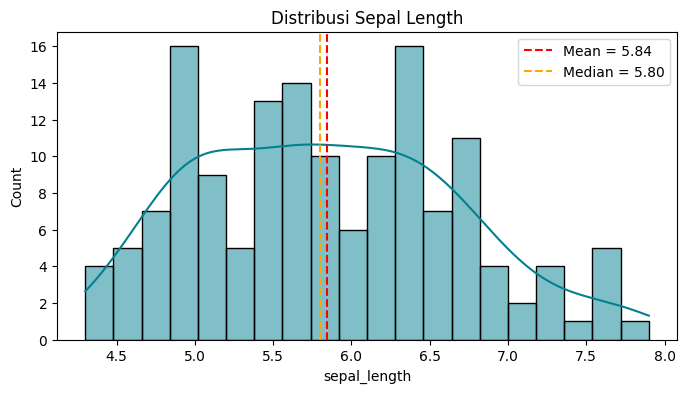

In [3]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    color='#028090',
    bins=20,
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.legend()

plt.show()

# Boxplot per Spesies

/tmp/ipykernel_5491/1552083014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5491/1552083014.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


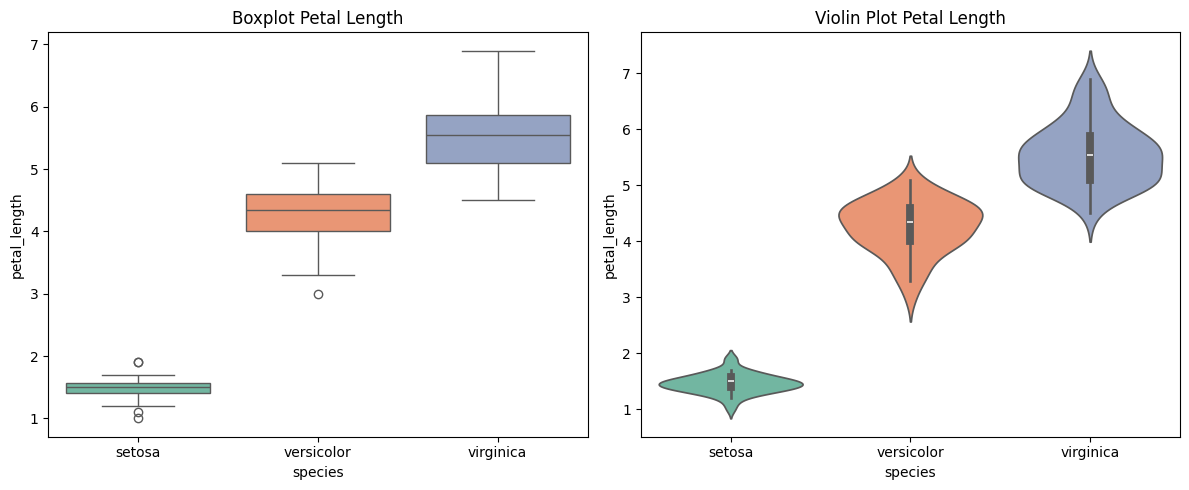

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

# Matriks Korelasi Pearson

In [5]:
# Menghitung korelasi Pearson
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

# Mencari pasangan korelasi tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'\nKorelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


# Scatter Plot & Heatmap

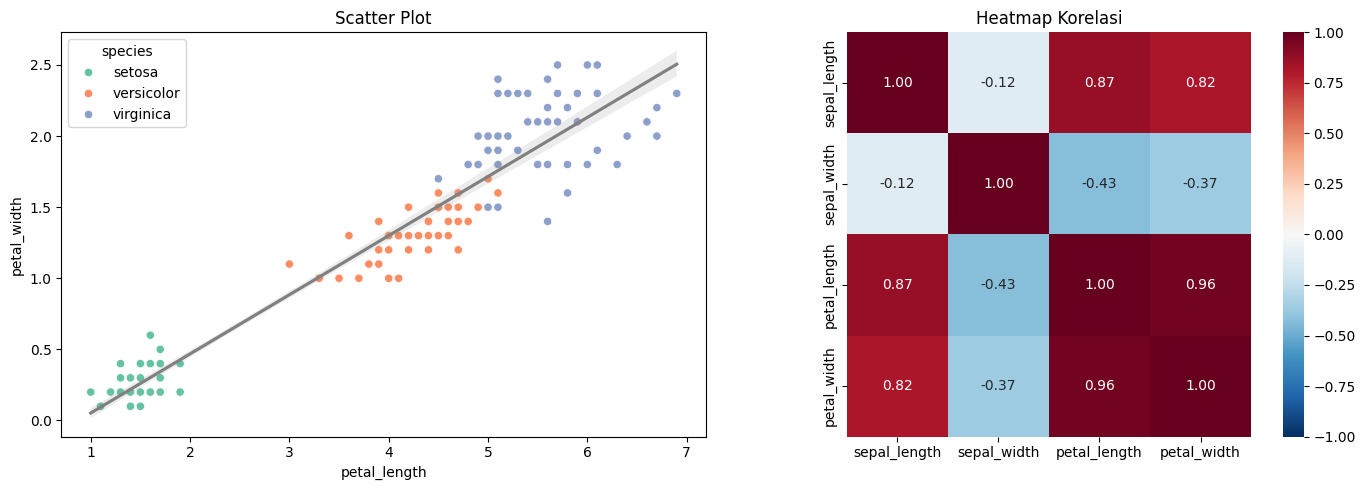

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter Plot')

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

### **Kesimpulan**

**Apa yang dipelajari:**
membahas konsep dasar statistika dan eksplorasi data menggunakan Python.

* Statistika Deskriptif: Cara meringkas data melalui ukuran pemusatan (Mean, Median, Modus) dan ukuran penyebaran (Varians, Standar Deviasi, IQR).
* Analisis Univariat & Distribusi: Menganalisis satu variabel untuk melihat bentuk sebaran datanya (Normal, Skewed, Bimodal) menggunakan metrik Skewness dan Kurtosis, serta visualisasi visualisasi seperti Histogram dan Boxplot.
* Analisis Bivariat: Mempelajari hubungan antar dua variabel menggunakan Scatter Plot, perhitungan korelasi (Pearson & Spearman), serta Heatmap.

**Temuan Utama:**
*   **Korelasi Tinggi:** Terdapat korelasi positif yang sangat kuat antara `petal_length` dan `petal_width` (0.96), yang menunjukkan bahwa kedua fitur ini berkembang secara proporsional.
*   **Pemisahan Spesies:** Spesies *Setosa* memiliki karakteristik fitur petal yang jauh lebih kecil dan terpisah secara jelas dibandingkan *Versicolor* dan *Virginica*.
*   **Distribusi:** Fitur `sepal_length` memiliki distribusi yang relatif normal dengan sedikit kemiringan (skewness) positif.

**Keterbatasan & Pertanyaan:**
*   **Ukuran Sampel:** Dataset relatif kecil (150 sampel), sehingga generalisasi untuk varietas iris lain mungkin terbatas.
*   **Analisis Lanjutan:** Apakah korelasi yang kuat ini dapat digunakan untuk membangun model klasifikasi dengan akurasi tinggi tanpa memerlukan seluruh fitur?